
# Markets & Fuels — Sanity Notebook
This notebook lets you **smoke-test** the end-to-end flow before production:
- Read config
- Fetch **ECB EURUSD** via the *ECB Data Portal API*
- Fetch **Brent (BZ=F)** via Yahoo Finance
- Derive **EUR** prices and add flags
- Write & read **Parquet** output

> Run this in a clean virtual environment with:  
> `pip install pandas requests yfinance pyarrow matplotlib`


In [61]:

from dataclasses import dataclass, field
from typing import Dict
import os
from pathlib import Path
import re

@dataclass
class Settings:
    http_timeout: int = field(default_factory=lambda: int(os.getenv("HTTP_TIMEOUT", 30)))
    ecb_base: str = field(default_factory=lambda: os.getenv("ECB_API_BASE", "https://data-api.ecb.europa.eu/service"))
    tickers: Dict[str, str] = field(default_factory=dict)

    def __post_init__(self):
        self.tickers.update({
            "brent_usd_bbl": os.getenv("YF_TICK_BRNT", "BZ=F"),
            "stoxx_eur_pts": os.getenv("YF_TICK_STOXX", "^STOXX50E"),
            "ibex_eur_pts":  os.getenv("YF_TICK_IBEX", "^IBEX"),
            "cac_eur_pts":   os.getenv("YF_TICK_CAC", "^FCHI"),
            "psi_eur_pts": os.getenv("YF_TICK_PSI", "PSI20.LS"),
        })
        self.tickers = {k.lower(): v for k, v in self.tickers.items() if v}

    def get_ticker(self, key: str) -> str:
        k = key.lower()
        if k not in self.tickers or not self.tickers[k]:
            raise KeyError(f"Missing ticker for '{key}'. Set YF_TICK_* env var.")
        return self.tickers[k]

settings = Settings()
settings.ecb_base, settings.get_ticker("brent_usd_bbl")


('https://data-api.ecb.europa.eu/service', 'BZ=F')

In [4]:

import pandas as pd
import requests

KEY = "D.USD.EUR.SP00.A"  # daily USD per EUR reference rate

def fetch_eur_usd(start: str, end: str, http_timeout: int = None) -> pd.DataFrame:
    base = settings.ecb_base.rstrip("/")
    url = (
        f"{base}/data/EXR/{KEY}"
        f"?startPeriod={start}&endPeriod={end}"
        f"&detail=dataonly&format=jsondata"
    )
    r = requests.get(url, timeout=http_timeout or settings.http_timeout)
    r.raise_for_status()
    data = r.json()

    time_vals = data["structure"]["dimensions"]["observation"][0]["values"]
    series_dict = data["dataSets"][0]["series"]
    rows = []
    for serie in series_dict.values():
        for idx_str, arr in serie.get("observations", {}).items():
            t = time_vals[int(idx_str)]["id"]
            v = arr[0]
            rows.append({"date": t, "eurusd": float(v)})

    fx = pd.DataFrame(rows)
    if fx.empty:
        return pd.DataFrame(columns=["date", "eurusd", "usdeur", "source"])

    # Normalize to tz-naive midnight
    fx["date"] = pd.to_datetime(fx["date"]).dt.normalize()

    fx = fx.sort_values("date").reset_index(drop=True)
    fx["usdeur"] = 1.0 / fx["eurusd"]
    fx["source"] = "ecb:data-api"
    return fx

fx_demo = fetch_eur_usd("2021-05-01", "2025-04-30")
fx_demo.head(), fx_demo.tail(), len(fx_demo)


(        date  eurusd    usdeur        source
 0 2021-05-03  1.2044  0.830289  ecb:data-api
 1 2021-05-04  1.2021  0.831878  ecb:data-api
 2 2021-05-05  1.2005  0.832986  ecb:data-api
 3 2021-05-06  1.2060  0.829187  ecb:data-api
 4 2021-05-07  1.2059  0.829256  ecb:data-api,
            date  eurusd    usdeur        source
 1021 2025-04-24  1.1376  0.879044  ecb:data-api
 1022 2025-04-25  1.1357  0.880514  ecb:data-api
 1023 2025-04-28  1.1358  0.880437  ecb:data-api
 1024 2025-04-29  1.1373  0.879275  ecb:data-api
 1025 2025-04-30  1.1373  0.879275  ecb:data-api,
 1026)

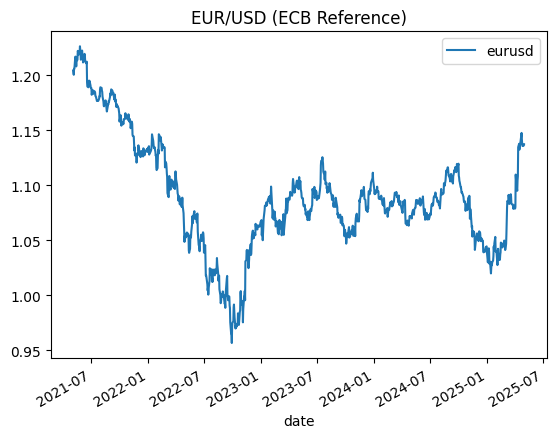

In [5]:

import matplotlib.pyplot as plt

if not fx_demo.empty:
    fx_demo.plot(x="date", y="eurusd", title="EUR/USD (ECB Reference)")
    plt.show()
else:
    print("ECB fetch returned empty dataframe for the given dates.")


In [62]:
import yfinance as yf

def _normalize_dtindex_to_naive_midnight_utc(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure df.index is tz-naive midnight (UTC-normalized day).
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        return df
    # If tz-aware, convert to UTC
    if df.index.tz is not None:
        df = df.tz_convert("UTC")
    # Drop tz & floor to day
    df.index = df.index.tz_localize(None).normalize()
    return df

def fetch_brent(start: str, end: str) -> pd.DataFrame:
    series_key = "psi_eur_pts"                   
    sym = settings.get_ticker(series_key)  
    y = yf.Ticker(sym)
    df = y.history(start=start, end=end, auto_adjust=False)

    if df.empty:
        return pd.DataFrame(columns=["date", "series", "value", "source"])

    df = _normalize_dtindex_to_naive_midnight_utc(df)

    out = (
        df[["Close"]]
        .rename(columns={"Close": "value"})
        .reset_index()
        .rename(columns={"Date": "date"})
    )
    out["series"] = f"{series_key}"
    out["source"] = f"yahoo:{sym}"
    return out[["date", "series", "value", "source"]]

br_demo = fetch_brent("2021-05-01", "2025-04-30")
br_demo.head(), len(br_demo)

(        date       series        value          source
 0 2021-05-02  psi_eur_pts  5131.209961  yahoo:PSI20.LS
 1 2021-05-03  psi_eur_pts  5045.319824  yahoo:PSI20.LS
 2 2021-05-05  psi_eur_pts  5091.609863  yahoo:PSI20.LS
 3 2021-05-06  psi_eur_pts  5149.220215  yahoo:PSI20.LS
 4 2021-05-09  psi_eur_pts  5177.069824  yahoo:PSI20.LS,
 1019)

In [63]:
_EUR_TOKEN = re.compile(r"(?<=_)eur(?=_)")
_USD_TOKEN = re.compile(r"(?<=_)usd(?=_)")

def _is_eur_series(name: str) -> bool:
    return bool(_EUR_TOKEN.search(str(name)))

def convert_usd_to_eur(
    prices: pd.DataFrame,
    fx: pd.DataFrame,
    out_series: str,
    ffill_fx: bool = True
) -> pd.DataFrame:
    """
    Merge daily prices with ECB FX and convert to EUR.
    If the target (or input) series already indicates EUR, skip conversion and passthrough.
    """
    # empty guards
    if prices.empty:
        return pd.DataFrame(columns=["date", "series", "value", "source", "is_estimated", "is_ffill"])

    # Normalize dates first (needed in both branches)
    prices = prices.copy()
    prices["date"] = pd.to_datetime(prices["date"]).dt.normalize()

    # If target series already EUR (e.g., 'brent_eur_bbl'), or input already EUR, skip conversion
    in_series_unique = prices.get("series")
    input_is_eur = False
    if in_series_unique is not None:
        uniq = pd.Series(in_series_unique.dropna().unique(), dtype="object")
        input_is_eur = len(uniq) > 0 and all(_is_eur_series(s) for s in uniq)

    if _is_eur_series(out_series) and input_is_eur:
        out = prices[["date", "series", "value", "source"]].copy()
        # ensure output series label is exactly out_series
        out["series"] = out_series
        out["is_estimated"] = False     # no FX transformation applied
        out["is_ffill"] = False         # no FX ffill applied
        return out[["date", "series", "value", "source", "is_estimated", "is_ffill"]]

    # If we need conversion but FX is missing, return empty (consistent with original behavior)
    if fx.empty:
        return pd.DataFrame(columns=["date", "series", "value", "source", "is_estimated", "is_ffill"])

    # --- Convert USD -> EUR ---
    fx2 = fx[["date", "usdeur"]].copy()
    fx2["date"] = pd.to_datetime(fx2["date"]).dt.normalize()

    m = prices.merge(fx2, on="date", how="left")

    if ffill_fx:
        m = m.sort_values("date")
        m["usdeur"] = m["usdeur"].ffill()

    m["value"] = m["value"] * m["usdeur"]
    m["series"] = out_series
    m["is_estimated"] = True
    m["is_ffill"] = m["usdeur"].isna().shift(fill_value=False)

    out = m[["date", "series", "value", "source", "is_estimated", "is_ffill"]].copy()
    out = out.dropna(subset=["value"])
    return out

def add_flags(df: pd.DataFrame, estimated=False, ffill=False) -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    out["is_estimated"] = bool(estimated)
    if "is_ffill" not in out.columns:
        out["is_ffill"] = bool(ffill)
    return out

In [64]:
br_demo_flags = add_flags(br_demo, estimated=False, ffill=False)
src_series = br_demo_flags["series"].dropna().unique()
assert len(src_series) == 1, "Expected exactly one source series."
out_series = re.sub(r"(?<=_)usd(?=_)", "eur", src_series[0])

br_eur = convert_usd_to_eur(
    br_demo_flags[["date","series","value","source"]],
    fx_demo,
    out_series=out_series,
    ffill_fx=True
)

combined = pd.concat([br_demo_flags, br_eur], ignore_index=True)
combined.sort_values("date", inplace=True)
combined.drop_duplicates(subset=["date", "series"], keep="last", inplace=True)
combined.reset_index(drop=True, inplace=True)
combined.head(10), len(combined)

(        date       series        value          source  is_estimated  is_ffill
 0 2021-05-02  psi_eur_pts  5131.209961  yahoo:PSI20.LS         False     False
 1 2021-05-03  psi_eur_pts  5045.319824  yahoo:PSI20.LS         False     False
 2 2021-05-05  psi_eur_pts  5091.609863  yahoo:PSI20.LS         False     False
 3 2021-05-06  psi_eur_pts  5149.220215  yahoo:PSI20.LS         False     False
 4 2021-05-09  psi_eur_pts  5177.069824  yahoo:PSI20.LS         False     False
 5 2021-05-11  psi_eur_pts  5102.959961  yahoo:PSI20.LS         False     False
 6 2021-05-12  psi_eur_pts  5113.040039  yahoo:PSI20.LS         False     False
 7 2021-05-13  psi_eur_pts  5195.660156  yahoo:PSI20.LS         False     False
 8 2021-05-16  psi_eur_pts  5241.910156  yahoo:PSI20.LS         False     False
 9 2021-05-17  psi_eur_pts  5278.799805  yahoo:PSI20.LS         False     False,
 1019)

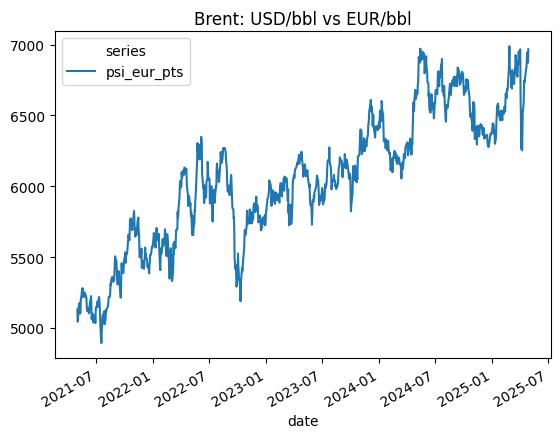

In [65]:
import matplotlib.pyplot as plt

if not combined.empty:
    pivot = combined.pivot(index="date", columns="series", values="value")
    ax = pivot.plot(title="Brent: USD/bbl vs EUR/bbl")
    plt.show()
else:
    print("No combined data to plot.")


In [66]:
combined.head(10), combined.dtypes


(        date       series        value          source  is_estimated  is_ffill
 0 2021-05-02  psi_eur_pts  5131.209961  yahoo:PSI20.LS         False     False
 1 2021-05-03  psi_eur_pts  5045.319824  yahoo:PSI20.LS         False     False
 2 2021-05-05  psi_eur_pts  5091.609863  yahoo:PSI20.LS         False     False
 3 2021-05-06  psi_eur_pts  5149.220215  yahoo:PSI20.LS         False     False
 4 2021-05-09  psi_eur_pts  5177.069824  yahoo:PSI20.LS         False     False
 5 2021-05-11  psi_eur_pts  5102.959961  yahoo:PSI20.LS         False     False
 6 2021-05-12  psi_eur_pts  5113.040039  yahoo:PSI20.LS         False     False
 7 2021-05-13  psi_eur_pts  5195.660156  yahoo:PSI20.LS         False     False
 8 2021-05-16  psi_eur_pts  5241.910156  yahoo:PSI20.LS         False     False
 9 2021-05-17  psi_eur_pts  5278.799805  yahoo:PSI20.LS         False     False,
 date            datetime64[ns]
 series                  object
 value                  float64
 source                

In [67]:
out_dir = Path("data")  # change if you like
out_dir.mkdir(parents=True, exist_ok=True)

for series_name, df_s in combined.groupby("series", dropna=False):
    # Make a safe filename from the series value
    name = "unknown_series" if pd.isna(series_name) or str(series_name).strip() == "" else str(series_name)
    safe = re.sub(r"[^A-Za-z0-9_.-]+", "_", name).strip("_")
    fp = out_dir / f"{safe}.parquet"

    df_s.sort_values("date").to_parquet(fp, index=False)